# Laptop Price Predictor
### Complete notebook: all 20 assignment steps

**Project goal:** predict a laptop's **price** from its specification (brand, processor, RAM, storage, screen, …).

The steps follow the order of the assignment document:

| Stage | Assignment steps |
|---|---|
| Data loading & understanding | 1 Import Library · 2 Data Loading · 3 Feature Extraction · 4 Data Info |
| Cleaning | 5 Checking missing data · 6 Missing Data Treatment · 7 Duplicate Checking · 8 Duplicate Removing |
| Exploration & feature engineering | 9 Data Visualization · 10 Correlation with target · 11 Features and target separation · 12 Feature Selection · 13 Feature Scaling · 14 PCA · 15 Encoding |
| Modelling | 16 Train Test Split · 17 Model Preparation · 18 Model Accuracy · 19 Cross_val function · 20 cross_val Accuracy |

**Input:** `Cleaned_Laptop_data.csv` (the only file needed).

**Running in Google Colab:** *Runtime → Run all*. If `Cleaned_Laptop_data.csv` is not already in the Colab file
panel, the Data Loading cell asks you to upload it.

## Step 1: Import Library

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sklearn
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import f_oneway
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from google.colab import files  # this import only works inside Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


def find_file(name):
    """Find a data file next to the notebook, in a data/ folder or in Colab's /content.
    In Colab, if the file is missing, ask for an upload."""
    for folder in [".", "data", "/content", "/content/data"]:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            return path
    if IN_COLAB:
        print(f"'{name}' was not found - please upload it.")
        uploaded = files.upload()
        return next(iter(uploaded))  # Colab saves the upload in /content
    raise FileNotFoundError(f"Put '{name}' next to this notebook (or in a data/ folder) and run again.")


# One quiet chart style for the whole project: recessive grid, data in color, text in ink.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, BLUE_LIGHT, ORANGE, RED = "#2a78d6", "#b7d3f6", "#eb6834", "#e34948"
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3de", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.prop_cycle": plt.cycler(color=SERIES), "font.size": 10, "figure.dpi": 100,
    "lines.linewidth": 2,
})
thousands = mticker.StrMethodFormatter("{x:,.0f}")

print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Running in Google Colab:", IN_COLAB)

numpy       : 2.4.6
pandas      : 3.0.6
scikit-learn: 1.9.1
Running in Google Colab: False


## Step 2: Data Loading

In [2]:
data_path = find_file("Cleaned_Laptop_data.csv")
raw = pd.read_csv(data_path)

print("Loaded:", data_path)
print("Shape :", raw.shape, "(rows, columns)")
raw.head(10)

Loaded: ./Cleaned_Laptop_data.csv
Shape : (845, 18) (rows, columns)


,brand,model,processor_brand,processor_Name,processor_gnrtn,ram_gb,Apps,ssd,hdd,os,os_bit,graphic_card_gb,weight,display_size,warranty,Touchscreen,msoffice,Price
0,ASUS,Celeron,Intel,5,Missing,4.0,Cooling,0,1024,Windows,64,0,Casual,15.6,1,No,No,23990.0
1,ASUS,VivoBook,Intel,5,10th,4.0,DDR3,512,0,Windows,64,0,Casual,15.6,1,No,No,37990.0
2,ASUS,Vivobook,Intel,A6-9225 Processor,10th,4.0,DDR3,0,1024,Windows,64,0,Casual,14.1,1,No,No,NaN
3,HP,Core,Intel,APU Dual,11th,4.0,DDR3,512,0,Windows,64,0,ThinNlight,15.6,1,No,Yes,54990.0
4,HP,Core,Intel,APU Dual,11th,4.0,DDR3,512,0,Windows,64,0,ThinNlight,15.6,0,No,No,54990.0
5,Lenovo,IdeaPad,Intel,APU Dual,10th,4.0,DDR3,0,1024,Windows,64,0,ThinNlight,15.6,1,No,Yes,35990.0
6,HP,15s,AMD,APU Dual,Missing,4.0,DDR3,256,1024,Windows,64,0,Casual,15.6,1,No,Yes,41999.0
7,ASUS,Core,Intel,APU Dual,11th,4.0,DDR3,256,0,Windows,64,0,ThinNlight,14,0,No,No,34429.0
8,DELL,Vostro,Intel,APU Dual,10th,4.0,DDR3,256,1024,Windows,64,0,ThinNlight,15.6,1,No,Yes,41490.0
9,Lenovo,IdeaPad,Intel,APU Dual,10th,4.0,DDR3,256,0,Windows,32,0,ThinNlight,15.6,2,No,Yes,37990.0


In [3]:
raw.tail(5)

,brand,model,processor_brand,processor_Name,processor_gnrtn,ram_gb,Apps,ssd,hdd,os,os_bit,graphic_card_gb,weight,display_size,warranty,Touchscreen,msoffice,Price
840,DELL,Inspiron,AMD,Ryzen 9,Missing,16.0,Unified,512,0,Windows,64,0,ThinNlight,15.6,0,No,No,42090.0
841,HP,Pavilion,AMD,Ryzen 9,Missing,16.0,Unified,512,0,Windows,64,4,Gaming,15.6,1,No,Yes,64990.0
842,ASUS,EeeBook,Intel,Ryzen 9,Missing,16.0,Unified,0,0,Windows,64,0,Casual,0,0,No,No,22990.0
843,HP,Pavilion,AMD,Slot for,Missing,16.0,Unified,512,0,Windows,64,2,Casual,14,1,No,Yes,79990.0
844,Lenovo,Ideapad,Intel,Snapdragon 7c,10th,16.0,Unified,512,0,Windows,64,2,Casual,14,1,Yes,Yes,86999.0


## Step 3: Feature Extraction

Feature extraction turns raw columns into clean features a model can use. First, a look at what each column
really contains:

In [4]:
pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "unique values": raw.nunique(),
    "example values": [raw[c].dropna().unique()[:6].tolist() for c in raw.columns],
})

,dtype,unique values,example values
brand,str,21,"[ASUS, HP, Lenovo, DELL, APPLE, acer]"
model,str,116,"[Celeron, VivoBook, Vivobook, Core, IdeaPad, 15s]"
processor_brand,str,10,"[Intel, AMD, Apple, MediaTek, NVIDIA, Qualcomm]"
processor_Name,str,34,"[5, A6-9225 Processor, APU Dual, Athlon Dual, ..."
processor_gnrtn,str,8,"[Missing, 10th, 11th, 9th, 8th, 7th]"
ram_gb,float64,5,"[4.0, 5.0, 8.0, 15.6, 16.0]"
Apps,str,14,"[Cooling, DDR3, DDR4, DDR5, Full, GTX]"
ssd,int64,8,"[0, 512, 256, 1024, 2048, 128]"
hdd,int64,3,"[1024, 0, 512]"
os,str,3,"[Windows, Mac, Missing]"


What the table shows, and what we extract from it:

| # | Problem in the raw data | Feature extraction |
|---|---|---|
| 3.1 | `Apps` holds RAM types (DDR4, LPDDR4X…), `weight` holds laptop categories (Casual, ThinNlight, Gaming); column names mix upper and lower case | Rename `Apps` → `ram_type`, `weight` → `laptop_type`; make every column name lower case |
| 3.2 | The same brand or model is written differently (`Lenovo` / `lenovo`, `VivoBook` / `Vivobook`) | Standardise the text: `brand` in upper case, `model` in lower case |
| 3.3 | `processor_gnrtn` is text such as `"11th"` | Extract the number → `processor_gen` = 11 |
| 3.4 | `processor_name` has 34 messy values (`Core i5`, `i5`, `Ryzen 7`, `M1 Pro`, `GeForce RTX`…) | Group them into a clean `cpu_family` (Intel Core i3/i5/i7/i9, AMD Ryzen 3/5/7/9, Apple M1, Entry level) |
| 3.5 | `display_size` is stored as text and contains words like `All`, `6th` | Convert to a number → `display_inch` |
| 3.6 | Storage is split across `ssd` and `hdd` | New feature `total_storage_gb` = `ssd` + `hdd` |

### 3.1 Rename columns

In [5]:
df = raw.copy()
df = df.rename(columns={"Apps": "ram_type", "weight": "laptop_type"})
df.columns = df.columns.str.lower()

print("Before:", raw.columns.tolist())
print("After :", df.columns.tolist())

Before: ['brand', 'model', 'processor_brand', 'processor_Name', 'processor_gnrtn', 'ram_gb', 'Apps', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb', 'weight', 'display_size', 'warranty', 'Touchscreen', 'msoffice', 'Price']
After : ['brand', 'model', 'processor_brand', 'processor_name', 'processor_gnrtn', 'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb', 'laptop_type', 'display_size', 'warranty', 'touchscreen', 'msoffice', 'price']


### 3.2 Standardise brand and model text

In [6]:
df["brand"] = df["brand"].str.strip().str.upper()
df["model"] = df["model"].str.strip().str.lower()

print("Unique brands:", raw["brand"].nunique(), "->", df["brand"].nunique())
print("Unique models:", raw["model"].nunique(), "->", df["model"].nunique())
print()
print(df["brand"].value_counts().to_string())

Unique brands: 21 -> 20
Unique models: 116 -> 106

brand
ASUS         246
DELL         147
LENOVO       141
HP           133
ACER          52
MSI           51
APPLE         27
AVITA         10
LG             5
VAIO           5
REALME         4
NOKIA          4
INFINIX        4
ALIENWARE      4
REDMIBOOK      3
MICROSOFT      3
MI             2
SMARTRON       2
SAMSUNG        1
IBALL          1


### 3.3 Processor generation: text → number

In [7]:
df["processor_gen"] = pd.to_numeric(df["processor_gnrtn"].str.extract(r"(\d+)")[0], errors="coerce")

(df.groupby("processor_gnrtn")
   .agg(processor_gen=("processor_gen", "first"), laptops=("processor_gen", "size"))
   .sort_values("processor_gen"))

,processor_gen,laptops
processor_gnrtn,,
4th,4.0,1
7th,7.0,9
8th,8.0,27
9th,9.0,5
10th,10.0,162
11th,11.0,334
12th,12.0,3
Missing,NaN,304


`"Missing"` has no number, so it becomes `NaN` (an empty value). Step 6 treats it.

### 3.4 Processor name → CPU family

In [8]:
ENTRY_LEVEL_WORDS = ["celeron", "pentium", "athlon", "apu", "dual core", "quad", "hexa",
                     "mediatek", "snapdragon", "a6-9225"]


def get_cpu_family(name):
    """Map a raw processor name to a clean CPU family. Names that are not a processor give NaN."""
    text = str(name).lower()
    intel = re.search(r"\bi([3579])\b", text)          # "core i5", "i5"
    if intel:
        return "Intel Core i" + intel.group(1)
    ryzen = re.search(r"ryzen\s*([3579])", text)       # "ryzen 7"
    if ryzen:
        return "AMD Ryzen " + ryzen.group(1)
    if "m1" in text:                                   # "m1 processor", "m1 pro", "m1 max"
        return "Apple M1"
    if any(word in text for word in ENTRY_LEVEL_WORDS):
        return "Entry level"
    return np.nan                                      # e.g. "GeForce RTX", "Genuine Windows"


df["cpu_family"] = df["processor_name"].apply(get_cpu_family)

(df.groupby("processor_name")
   .agg(cpu_family=("cpu_family", "first"), laptops=("cpu_family", "size"))
   .sort_values("laptops", ascending=False))

,cpu_family,laptops
processor_name,,
Core i5,Intel Core i5,274
Core i3,Intel Core i3,158
Core i7,Intel Core i7,103
Ryzen 5,AMD Ryzen 5,82
Ryzen 7,AMD Ryzen 7,57
Ryzen 9,AMD Ryzen 9,26
Ryzen 3,AMD Ryzen 3,24
Celeron Dual,Entry level,20
M1 Processor,Apple M1,17


In [9]:
print("processor_name:", df["processor_name"].nunique(), "values  ->  cpu_family:",
      df["cpu_family"].nunique(), "values\n")
print(df["cpu_family"].value_counts(dropna=False).to_string())

processor_name: 34 values  ->  cpu_family: 10 values

cpu_family
Intel Core i5    280
Intel Core i3    158
Intel Core i7    116
AMD Ryzen 5       82
AMD Ryzen 7       57
Entry level       54
AMD Ryzen 9       26
AMD Ryzen 3       24
Apple M1          23
NaN               18
Intel Core i9      7


Names such as `GeForce RTX` (a graphics card), `Genuine Windows` or `GB SSD` are not processors: they were put in
the wrong column when the data was scraped. They become `NaN` here and are treated in Step 6.

### 3.5 Display size: text → number

In [10]:
df["display_inch"] = pd.to_numeric(df["display_size"], errors="coerce")

print(df["display_inch"].value_counts(dropna=False).sort_index().to_string())

display_inch
0.00      58
12.00      1
12.20      2
13.00      7
13.30     77
13.40      7
13.50      6
14.00    268
14.10      7
14.20      3
14.90      1
14.96      9
15.00      6
15.30      1
15.60    358
16.00      8
16.10      7
16.20      3
17.30     13
NaN        3


Text that is not a size (`All`, `6th`, `8th`) became `NaN`. A screen of `0` inches is impossible; Step 5 counts
it as missing.

### 3.6 New feature: total storage

In [11]:
df["total_storage_gb"] = df["ssd"] + df["hdd"]

df[["ssd", "hdd", "total_storage_gb"]].value_counts().head(10)

ssd   hdd   total_storage_gb
512   0     512                 400
256   0     256                 117
1024  0     1024                109
256   1024  1280                 71
0     1024  1024                 69
      0     0                    60
128   0     128                   9
512   1024  1536                  3
2048  0     2048                  2
512   512   1024                  2
Name: count, dtype: int64

### 3.7 Drop the raw text columns that now have a numeric version

`processor_gnrtn` is replaced by `processor_gen`, and `display_size` by `display_inch`. `processor_name` stays for
now (`cpu_family` is a grouping of it); Step 12 decides which features the model keeps.

In [12]:
df = df.drop(columns=["processor_gnrtn", "display_size"])

print("Shape after feature extraction:", df.shape)
df.head()

Shape after feature extraction: (845, 20)


,brand,model,processor_brand,processor_name,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,laptop_type,warranty,touchscreen,msoffice,price,processor_gen,cpu_family,display_inch,total_storage_gb
0,ASUS,celeron,Intel,5,4.0,Cooling,0,1024,Windows,64,0,Casual,1,No,No,23990.0,NaN,NaN,15.6,1024
1,ASUS,vivobook,Intel,5,4.0,DDR3,512,0,Windows,64,0,Casual,1,No,No,37990.0,10.0,NaN,15.6,512
2,ASUS,vivobook,Intel,A6-9225 Processor,4.0,DDR3,0,1024,Windows,64,0,Casual,1,No,No,NaN,10.0,Entry level,14.1,1024
3,HP,core,Intel,APU Dual,4.0,DDR3,512,0,Windows,64,0,ThinNlight,1,No,Yes,54990.0,11.0,Entry level,15.6,512
4,HP,core,Intel,APU Dual,4.0,DDR3,512,0,Windows,64,0,ThinNlight,0,No,No,54990.0,11.0,Entry level,15.6,512


## Step 4: Data Info

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             845 non-null    str    
 1   model             845 non-null    str    
 2   processor_brand   845 non-null    str    
 3   processor_name    845 non-null    str    
 4   ram_gb            845 non-null    float64
 5   ram_type          845 non-null    str    
 6   ssd               845 non-null    int64  
 7   hdd               845 non-null    int64  
 8   os                845 non-null    str    
 9   os_bit            845 non-null    int64  
 10  graphic_card_gb   845 non-null    int64  
 11  laptop_type       845 non-null    str    
 12  warranty          845 non-null    int64  
 13  touchscreen       845 non-null    str    
 14  msoffice          845 non-null    str    
 15  price             842 non-null    float64
 16  processor_gen     541 non-null    float64
 17  cpu_fami

In [14]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ram_gb,845.0,9.77,4.11,4.0,8.0,8.0,16.0,16.0
ssd,845.0,444.48,315.17,0.0,256.0,512.0,512.0,3072.0
hdd,845.0,175.72,385.50,0.0,0.0,0.0,0.0,1024.0
os_bit,845.0,59.34,11.29,32.0,64.0,64.0,64.0,64.0
graphic_card_gb,845.0,1.23,2.08,0.0,0.0,0.0,2.0,8.0
warranty,845.0,0.71,0.61,0.0,0.0,1.0,1.0,3.0
price,842.0,77355.59,47077.04,13990.0,46322.5,63990.0,91740.0,441990.0
processor_gen,541.0,10.46,0.93,4.0,10.0,11.0,11.0,12.0
display_inch,842.0,13.75,3.86,0.0,14.0,14.0,15.6,17.3
total_storage_gb,845.0,620.19,375.42,0.0,512.0,512.0,1024.0,3072.0


In [15]:
df.describe(exclude="number").T

,count,unique,top,freq
brand,845,20,ASUS,246
model,845,106,core,87
processor_brand,845,10,Intel,599
processor_name,845,34,Core i5,274
ram_type,845,14,DDR4,717
os,845,3,Windows,754
laptop_type,845,3,Casual,534
touchscreen,845,2,No,744
msoffice,845,2,No,564
cpu_family,827,10,Intel Core i5,280


In [16]:
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non-null": df.notna().sum(),
    "NaN": df.isna().sum(),
    "unique": df.nunique(),
}).sort_values("NaN", ascending=False)

,dtype,non-null,NaN,unique
processor_gen,float64,541,304,7
cpu_family,str,827,18,10
price,float64,842,3,403
display_inch,float64,842,3,19
processor_name,str,845,0,34
processor_brand,str,845,0,10
model,str,845,0,106
brand,str,845,0,20
ram_gb,float64,845,0,5
ram_type,str,845,0,14


In [17]:
for col in ["os", "ram_type", "laptop_type", "processor_brand", "touchscreen", "msoffice"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().to_string(), end="\n\n")

--- os ---
os
Windows    754
Missing     64
Mac         27

--- ram_type ---
ram_type
DDR4        717
LPDDR4X      65
LPDDR3       14
DDR3         12
LPDDR4       11
DDR5          7
Full          6
Unified       6
GTX           2
Cooling       1
i5            1
LED           1
Master        1
ram_type      1

--- laptop_type ---
laptop_type
Casual        534
ThinNlight    273
Gaming         38

--- processor_brand ---
processor_brand
Intel            599
AMD              205
Apple             23
NVIDIA             7
MediaTek           3
Pre-installed      3
First              2
Qualcomm           1
512                1
M.2                1

--- touchscreen ---
touchscreen
No     744
Yes    101

--- msoffice ---
msoffice
No     564
Yes    281



### What Data Info tells us

- **845 laptops × 20 columns** after feature extraction: 10 numeric and 10 text columns.
- **Visible missing values (`NaN`)**: `processor_gen` 304 (the generation was written as `"Missing"`),
  `cpu_family` 18 (the processor name was not a processor), `price` 3 and `display_inch` 3.
- **Hidden missing values** that look like real data: `os` = `"Missing"` (64 laptops), a screen size of 0 inches
  (58), RAM of 15.6 GB or 5 GB (7), non-CPU makers in `processor_brand` (NVIDIA, M.2, 512…), non-RAM values in
  `ram_type` (GTX, LED, Cooling…), and 60 laptops with 0 GB of storage.
- **Price** ranges from 13,990 to 441,990. The mean (77,356) is well above the median (63,990), so a few very
  expensive laptops pull the average up.
- Most laptops are ASUS (246), run Windows (754), use DDR4 RAM (717) and are `Casual` laptops (534).

Steps 5–8 handle all of these problems.

## Step 5: Checking missing data

### 5.1 Missing values pandas can see (`NaN`)

In [18]:
def missing_table(frame):
    counts = frame.isna().sum()
    table = pd.DataFrame({"missing": counts, "percent": (counts / len(frame) * 100).round(1)})
    return table[table["missing"] > 0].sort_values("missing", ascending=False)


missing_table(df)

,missing,percent
processor_gen,304,36.0
cpu_family,18,2.1
price,3,0.4
display_inch,3,0.4


### 5.2 Hidden missing values

Some gaps are written as text (`"Missing"`) or as impossible values, so `isna()` cannot see them.
Each rule below finds one kind of hidden missing value:

In [19]:
VALID_RAM_GB = [4, 8, 16, 32]                                   # RAM is sold in these sizes
VALID_CPU_BRANDS = ["Intel", "AMD", "Apple", "MediaTek", "Qualcomm"]
no_storage = df["ssd"].eq(0) & df["hdd"].eq(0)                  # a laptop always has some storage

hidden_rules = [
    # (column,          what is wrong,                               rows affected)
    ("os",              'text "Missing"',                            df["os"].eq("Missing")),
    ("display_inch",    "screen size of 0 inches",                   df["display_inch"].eq(0)),
    ("ram_gb",          "RAM size that does not exist (15.6, 5)",    ~df["ram_gb"].isin(VALID_RAM_GB)),
    ("processor_brand", "not a CPU maker (NVIDIA, M.2, 512, ...)",   ~df["processor_brand"].isin(VALID_CPU_BRANDS)),
    ("ram_type",        "not a RAM type (GTX, LED, Cooling, ...)",   ~df["ram_type"].str.contains("DDR|Unified", na=False)),
    ("ssd",             "no SSD and no HDD (0 GB storage)",          no_storage),
    ("total_storage_gb", "0 GB storage",                             no_storage),
]

pd.DataFrame(
    [(col, rule, int(mask.sum()), df.loc[mask, col].unique()[:6].tolist()) for col, rule, mask in hidden_rules],
    columns=["column", "hidden missing value", "rows", "values found"],
)

,column,hidden missing value,rows,values found
0,os,"text ""Missing""",64,[Missing]
1,display_inch,screen size of 0 inches,58,[0.0]
2,ram_gb,"RAM size that does not exist (15.6, 5)",7,"[5.0, 15.6]"
3,processor_brand,"not a CPU maker (NVIDIA, M.2, 512, ...)",14,"[NVIDIA, Pre-installed, First, 512, M.2]"
4,ram_type,"not a RAM type (GTX, LED, Cooling, ...)",13,"[Cooling, Full, GTX, i5, LED, Master]"
5,ssd,no SSD and no HDD (0 GB storage),60,[0]
6,total_storage_gb,0 GB storage,60,[0]


Replace every hidden missing value with a real `NaN`, so all gaps are counted and treated the same way:

In [20]:
for col, rule, mask in hidden_rules:
    df[col] = df[col].mask(mask)        # mask() puts NaN where the rule is True

missing_before = missing_table(df)
missing_before

,missing,percent
processor_gen,304,36.0
os,64,7.6
display_inch,61,7.2
ssd,60,7.1
total_storage_gb,60,7.1
cpu_family,18,2.1
processor_brand,14,1.7
ram_type,13,1.5
ram_gb,7,0.8
price,3,0.4


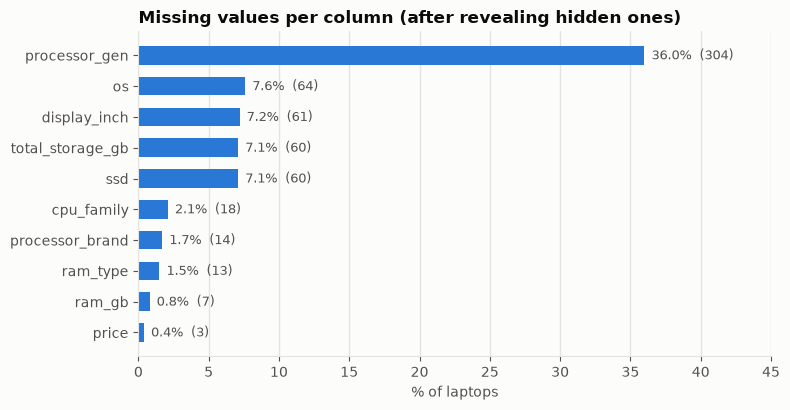

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_data = missing_before.sort_values("percent")
ax.barh(plot_data.index, plot_data["percent"], color=BLUE, height=0.6)
for y, (pct, n) in enumerate(zip(plot_data["percent"], plot_data["missing"])):
    ax.text(pct + 0.5, y, f"{pct:.1f}%  ({n})", va="center", color=INK_2, fontsize=9)
ax.set_title("Missing values per column (after revealing hidden ones)")
ax.set_xlabel("% of laptops")
ax.set_xlim(0, plot_data["percent"].max() * 1.25)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

After the hidden values are revealed, **10 columns have gaps**. `processor_gen` is the biggest problem
(36% missing); every other column is under 8%.

## Step 6: Missing Data Treatment

| Column | Treatment | Why |
|---|---|---|
| `price` | **Drop the rows** | It is the target. Filling it in would invent the answer the model must learn. |
| `processor_gen`, `display_inch`, `ssd` | **Median** | Numeric; the median is not pulled by very cheap or very expensive laptops. |
| `total_storage_gb` | **Recompute** as `ssd + hdd` | Keeps it consistent with the imputed `ssd`. |
| `ram_gb` | **Mode** (most common size) | RAM comes in fixed sizes; a median could give a size that does not exist. |
| `os`, `processor_brand`, `ram_type`, `cpu_family` | **Mode** (most common value) | Categorical columns have no average. |

### 6.1 Drop rows with no price (target)

In [22]:
before = len(df)
df = df.dropna(subset=["price"]).reset_index(drop=True)
print(f"Rows without a price removed: {before - len(df)}  ({before} -> {len(df)} rows)")

Rows without a price removed: 3  (845 -> 842 rows)


### 6.2 Numeric columns → median

In [23]:
for col in ["processor_gen", "display_inch", "ssd"]:
    n_missing = int(df[col].isna().sum())
    median = df[col].median()
    df[col] = df[col].fillna(median)
    print(f"{col:<15} {n_missing:>4} filled with median = {median}")

df["total_storage_gb"] = df["ssd"] + df["hdd"]
print("total_storage_gb recomputed as ssd + hdd")

processor_gen    303 filled with median = 11.0
display_inch      61 filled with median = 15.0
ssd               60 filled with median = 512.0
total_storage_gb recomputed as ssd + hdd


### 6.3 RAM and categorical columns → mode

In [24]:
for col in ["ram_gb", "os", "processor_brand", "ram_type", "cpu_family"]:
    n_missing = int(df[col].isna().sum())
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)
    print(f"{col:<16} {n_missing:>4} filled with mode = {mode}")

ram_gb              7 filled with mode = 8.0
os                 64 filled with mode = Windows
processor_brand    14 filled with mode = Intel
ram_type           13 filled with mode = DDR4
cpu_family         18 filled with mode = Intel Core i5


### 6.4 Tidy the data types and verify

In [25]:
for col in ["ram_gb", "ssd", "total_storage_gb", "processor_gen"]:
    df[col] = df[col].astype(int)        # these are whole numbers again after imputation

print("Missing values left:", int(df.isna().sum().sum()))
assert df.isna().sum().sum() == 0, "There are still missing values"
df.isna().sum().to_frame("missing").T

Missing values left: 0


,brand,model,processor_brand,processor_name,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,laptop_type,warranty,touchscreen,msoffice,price,processor_gen,cpu_family,display_inch,total_storage_gb
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


`processor_name` keeps its original text (including a few non-processor values such as `GB SSD`). The clean
version of that information is `cpu_family`; Step 12 decides which of the two the model uses.

## Step 7: Duplicate Checking

A duplicate row is the same laptop listed twice. If it stays, the model can see the same laptop in both the
training and the test set, which makes the accuracy look better than it really is.

In [26]:
n_dup = int(df.duplicated().sum())
print("Duplicate rows (exact copies of an earlier row):", n_dup)

Duplicate rows (exact copies of an earlier row): 10


In [27]:
# Every copy, sorted so that duplicates sit next to each other
dup_rows = df[df.duplicated(keep=False)]
dup_rows.sort_values(list(df.columns))

,brand,model,processor_brand,processor_name,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,laptop_type,warranty,touchscreen,msoffice,price,processor_gen,cpu_family,display_inch,total_storage_gb
215,APPLE,2021,Apple,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,225990.0,11,Intel Core i5,14.2,1024
293,APPLE,2021,Apple,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,225990.0,11,Intel Core i5,14.2,1024
284,APPLE,macbook,Intel,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,179990.0,10,Intel Core i5,13.0,1024
333,APPLE,macbook,Intel,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,179990.0,10,Intel Core i5,13.0,1024
308,ASUS,pentium,Intel,Core i5,8,DDR4,0,1024,Windows,64,0,Casual,1,No,No,25990.0,11,Intel Core i5,15.6,1024
310,ASUS,pentium,Intel,Core i5,8,DDR4,0,1024,Windows,64,0,Casual,1,No,No,25990.0,11,Intel Core i5,15.6,1024
51,ASUS,vivobook,AMD,Core i3,4,DDR4,256,1024,Windows,64,0,Casual,1,No,No,54990.0,11,Intel Core i3,15.6,1280
82,ASUS,vivobook,AMD,Core i3,4,DDR4,256,1024,Windows,64,0,Casual,1,No,No,54990.0,11,Intel Core i3,15.6,1280
237,ASUS,vivobook,AMD,Core i5,8,DDR4,512,0,Windows,64,0,Casual,1,No,No,58990.0,11,Intel Core i5,14.0,512
386,ASUS,vivobook,AMD,Core i5,8,DDR4,512,0,Windows,64,0,Casual,1,No,No,58990.0,11,Intel Core i5,14.0,512


## Step 8: Duplicate Removing

In [28]:
before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Duplicate rows removed: {before - len(df)}  ({before} -> {len(df)} rows)")

assert df.duplicated().sum() == 0, "Duplicates are still present"
print("Duplicates left:", int(df.duplicated().sum()))

Duplicate rows removed: 10  (842 -> 832 rows)
Duplicates left: 0


### The clean data

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             832 non-null    str    
 1   model             832 non-null    str    
 2   processor_brand   832 non-null    str    
 3   processor_name    832 non-null    str    
 4   ram_gb            832 non-null    int64  
 5   ram_type          832 non-null    str    
 6   ssd               832 non-null    int64  
 7   hdd               832 non-null    int64  
 8   os                832 non-null    str    
 9   os_bit            832 non-null    int64  
 10  graphic_card_gb   832 non-null    int64  
 11  laptop_type       832 non-null    str    
 12  warranty          832 non-null    int64  
 13  touchscreen       832 non-null    str    
 14  msoffice          832 non-null    str    
 15  price             832 non-null    float64
 16  processor_gen     832 non-null    int64  
 17  cpu_fami

## Step 9: Data Visualization

### 9.1 How are prices distributed?

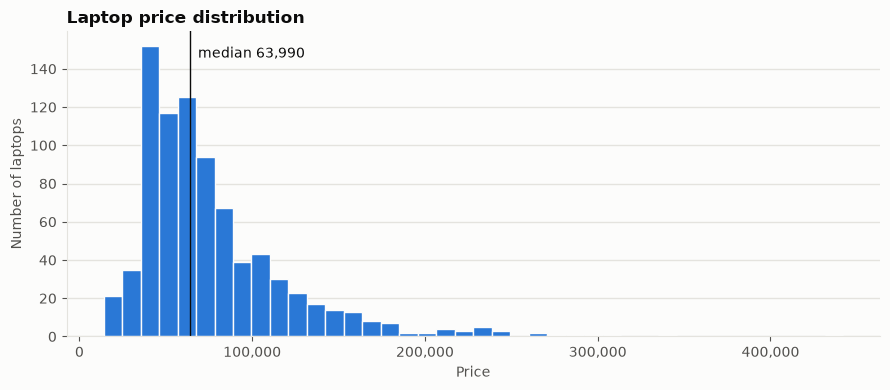

count       832.0
mean      77248.0
std       46875.0
min       13990.0
25%       46148.0
50%       63990.0
75%       91992.0
max      441990.0
Skewness: 2.35


In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["price"], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=1)
median_price = df["price"].median()
ax.axvline(median_price, color=INK, linewidth=1)
ax.text(median_price, ax.get_ylim()[1] * 0.95, f"  median {median_price:,.0f}", color=INK, va="top")
ax.set_title("Laptop price distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Number of laptops")
ax.xaxis.set_major_formatter(thousands)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(df["price"].describe().round(0).to_string())
print("Skewness:", round(df["price"].skew(), 2))

Prices are **right-skewed** (skewness 2.35): the middle half of the laptops cost between about 46,000 and
92,000, with a long tail of expensive models up to 441,990. The median (63,990) is a better "typical price"
than the mean (77,248).

### 9.2 Which brands are in the data, and how expensive are they?

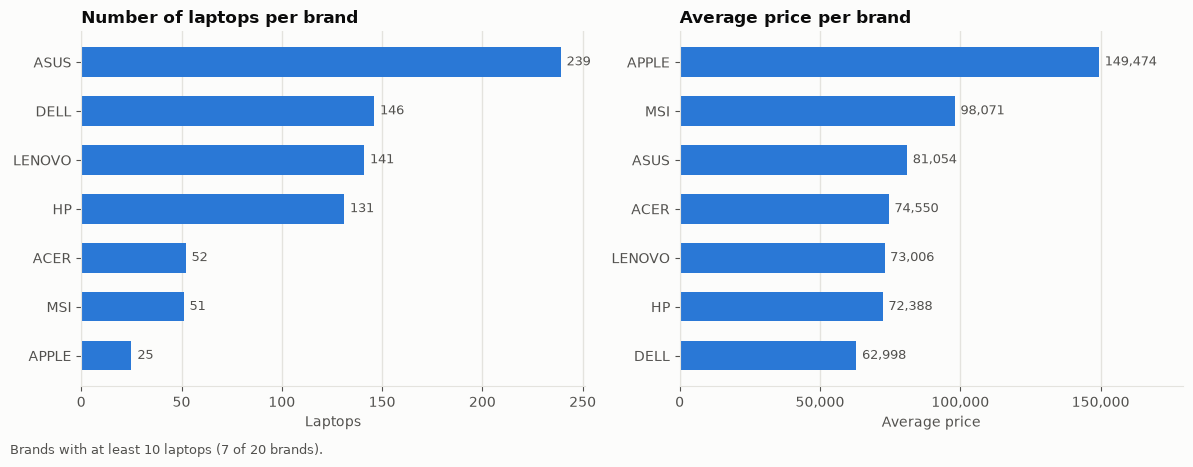

In [31]:
brand_stats = df.groupby("brand")["price"].agg(laptops="size", avg_price="mean").sort_values("laptops")
big_brands = brand_stats[brand_stats["laptops"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(big_brands.index, big_brands["laptops"], color=BLUE, height=0.6)
for y, n in enumerate(big_brands["laptops"]):
    axes[0].text(n + 3, y, str(n), va="center", color=INK_2, fontsize=9)
axes[0].set_title("Number of laptops per brand")
axes[0].set_xlabel("Laptops")

by_price = big_brands.sort_values("avg_price")
axes[1].barh(by_price.index, by_price["avg_price"], color=BLUE, height=0.6)
for y, p in enumerate(by_price["avg_price"]):
    axes[1].text(p + 2000, y, f"{p:,.0f}", va="center", color=INK_2, fontsize=9)
axes[1].set_title("Average price per brand")
axes[1].set_xlabel("Average price")
axes[1].xaxis.set_major_formatter(thousands)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(4))
axes[1].set_xlim(0, by_price["avg_price"].max() * 1.2)
for ax in axes:
    ax.grid(axis="y", visible=False)
fig.text(0.01, -0.02, f"Brands with at least 10 laptops ({len(big_brands)} of {len(brand_stats)} brands).",
         color=INK_2, fontsize=9)
plt.tight_layout()
plt.show()

ASUS, DELL, LENOVO and HP make up most of the data. **APPLE** is by far the most expensive brand on average
(about 149,000), followed by **MSI** (gaming laptops, about 98,000). DELL is the cheapest of the big brands
(about 63,000). Brand clearly matters for price.

### 9.3 Price by CPU family

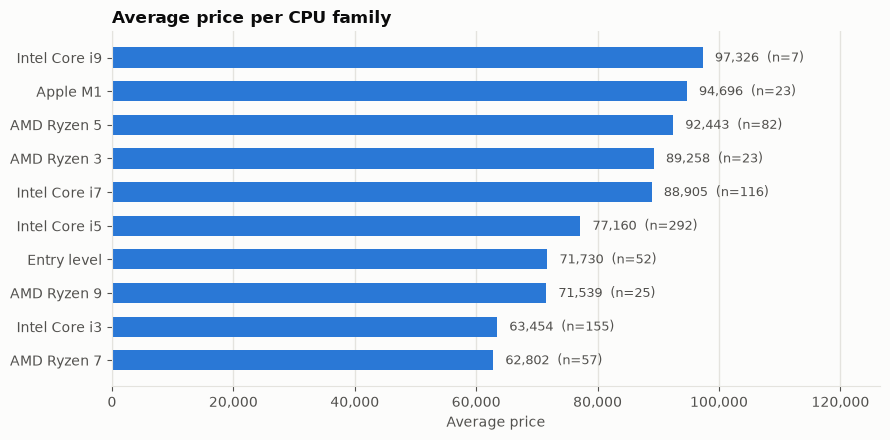

In [32]:
cpu_stats = df.groupby("cpu_family")["price"].agg(laptops="size", avg_price="mean").sort_values("avg_price")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(cpu_stats.index, cpu_stats["avg_price"], color=BLUE, height=0.6)
for y, (p, n) in enumerate(zip(cpu_stats["avg_price"], cpu_stats["laptops"])):
    ax.text(p + 2000, y, f"{p:,.0f}  (n={n})", va="center", color=INK_2, fontsize=9)
ax.set_title("Average price per CPU family")
ax.set_xlabel("Average price")
ax.xaxis.set_major_formatter(thousands)
ax.set_xlim(0, cpu_stats["avg_price"].max() * 1.3)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

A faster CPU family does not always mean a higher price here. The Core i9 and Apple M1 are at the top, but the
Ryzen 7 has the lowest average of all (62,802), just below the Core i3, while the Ryzen 3 averages 89,258.
In some rows of this scraped dataset, values landed in the wrong column, so a single feature can be noisy.
That is one reason the models in Steps 16–20 reach moderate, not perfect, accuracy.

### 9.4 Price by RAM size and laptop type

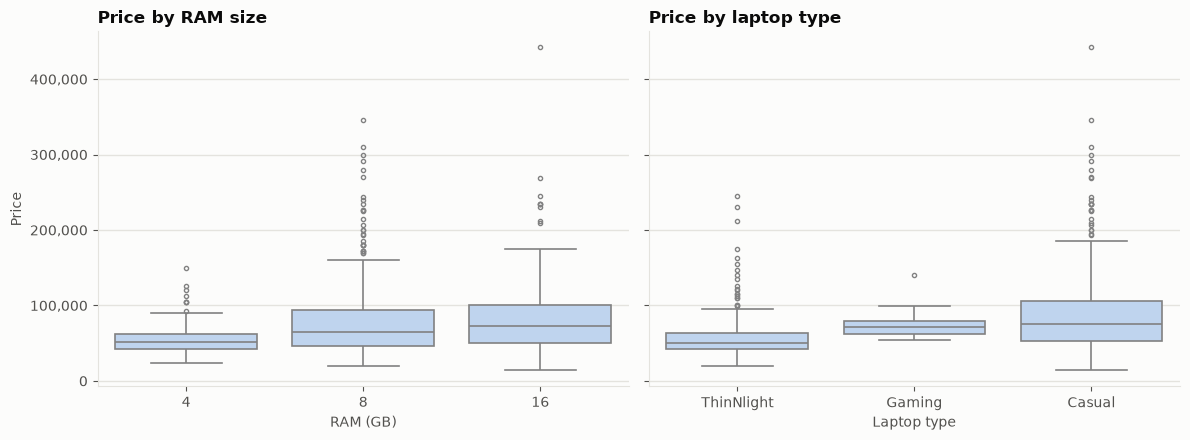

ram_gb
4     51990.0
8     64990.0
16    73400.0

laptop_type
Casual        74990.0
Gaming        71990.0
ThinNlight    49990.0


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
box_style = dict(color=BLUE_LIGHT, linewidth=1.2, fliersize=3)

sns.boxplot(data=df, x="ram_gb", y="price", ax=axes[0], **box_style)
axes[0].set_title("Price by RAM size")
axes[0].set_xlabel("RAM (GB)")

type_order = df.groupby("laptop_type")["price"].median().sort_values().index
sns.boxplot(data=df, x="laptop_type", y="price", order=type_order, ax=axes[1], **box_style)
axes[1].set_title("Price by laptop type")
axes[1].set_xlabel("Laptop type")

axes[0].set_ylabel("Price")
axes[0].yaxis.set_major_formatter(thousands)
for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(df.groupby("ram_gb")["price"].median().rename("median price").to_string(), end="\n\n")
print(df.groupby("laptop_type")["price"].median().rename("median price").to_string())

- **RAM:** the median price rises from 51,990 (4 GB) to 64,990 (8 GB) and 73,400 (16 GB), but the boxes overlap a
  lot, so RAM alone does not decide the price.
- **Laptop type:** `ThinNlight` laptops are the cheapest (median 49,990). `Casual` laptops have the widest
  range and include the most expensive models; the few `Gaming` laptops sit in a narrow band around 72,000.

### 9.5 Price by SSD size and graphics card memory

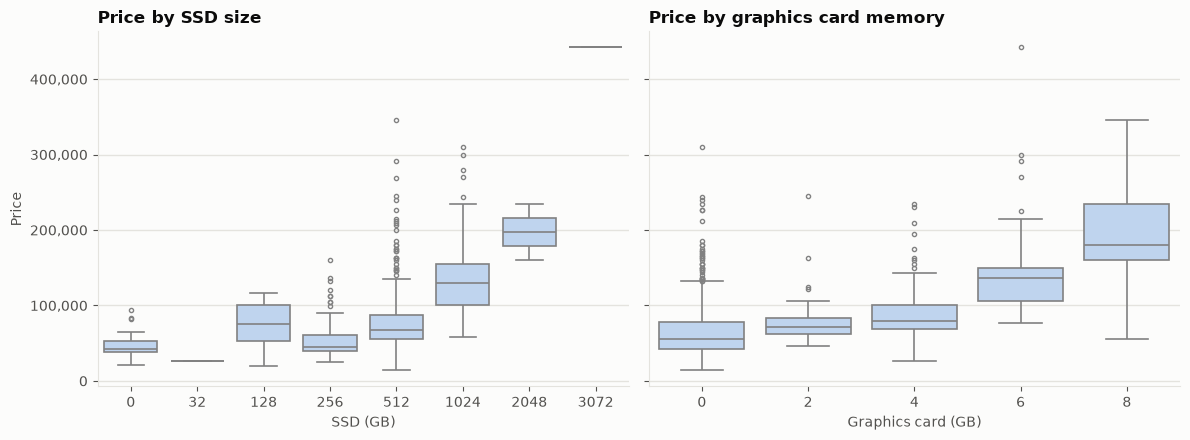

      size    median
ssd                 
0       67   42190.0
32       1   26899.0
128     10   75050.0
256    185   44490.0
512    459   68090.0
1024   107  129990.0
2048     2  196990.0
3072     1  441990.0

                 size    median
graphic_card_gb                
0                 578   54990.0
2                  64   70985.0
4                 133   79990.0
6                  40  136490.0
8                  17  179990.0


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

sns.boxplot(data=df, x="ssd", y="price", ax=axes[0], **box_style)
axes[0].set_title("Price by SSD size")
axes[0].set_xlabel("SSD (GB)")

sns.boxplot(data=df, x="graphic_card_gb", y="price", ax=axes[1], **box_style)
axes[1].set_title("Price by graphics card memory")
axes[1].set_xlabel("Graphics card (GB)")

axes[0].set_ylabel("Price")
axes[0].yaxis.set_major_formatter(thousands)
for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(df.groupby("ssd")["price"].agg(["size", "median"]).round(0).to_string(), end="\n\n")
print(df.groupby("graphic_card_gb")["price"].agg(["size", "median"]).round(0).to_string())

These two show the clearest pattern so far. The median price climbs with **SSD size** (68,090 at 512 GB →
129,990 at 1 TB → 196,990 at 2 TB) and with **graphics card memory** (54,990 with no dedicated card →
179,990 with 8 GB). Laptops with no SSD (HDD only) are among the cheapest.

## Step 10: Checking Correlation between target and other columns

Correlation (Pearson *r*) measures how strongly a numeric column moves with `price`:
+1 = rises together, −1 = one rises while the other falls, 0 = no straight-line relationship.

In [35]:
numeric_cols = df.select_dtypes(include="number").columns.drop("price").tolist()
corr_with_price = df[numeric_cols].corrwith(df["price"]).sort_values()

corr_with_price.to_frame("correlation with price").round(3)

,correlation with price
hdd,-0.210
display_inch,-0.070
os_bit,-0.069
processor_gen,0.007
warranty,0.026
ram_gb,0.124
total_storage_gb,0.286
graphic_card_gb,0.484
ssd,0.608


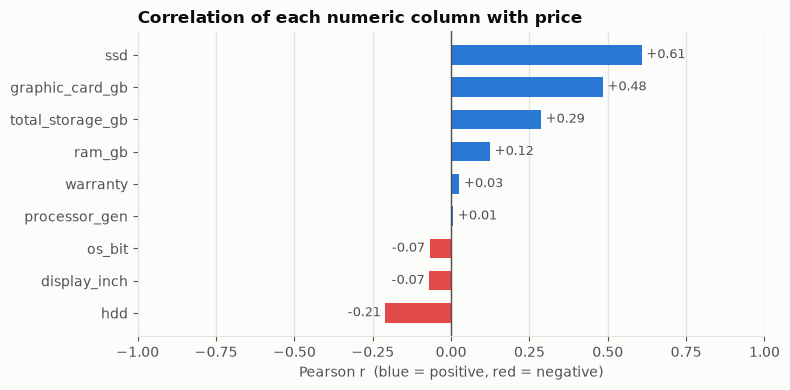

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [BLUE if r > 0 else RED for r in corr_with_price]
ax.barh(corr_with_price.index, corr_with_price, color=colors, height=0.6)
for y, r in enumerate(corr_with_price):
    ax.text(r + (0.015 if r >= 0 else -0.015), y, f"{r:+.2f}", va="center",
            ha="left" if r >= 0 else "right", color=INK_2, fontsize=9)
ax.axvline(0, color=INK_2, linewidth=1)
ax.set_title("Correlation of each numeric column with price")
ax.set_xlabel("Pearson r  (blue = positive, red = negative)")
ax.set_xlim(-1, 1)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

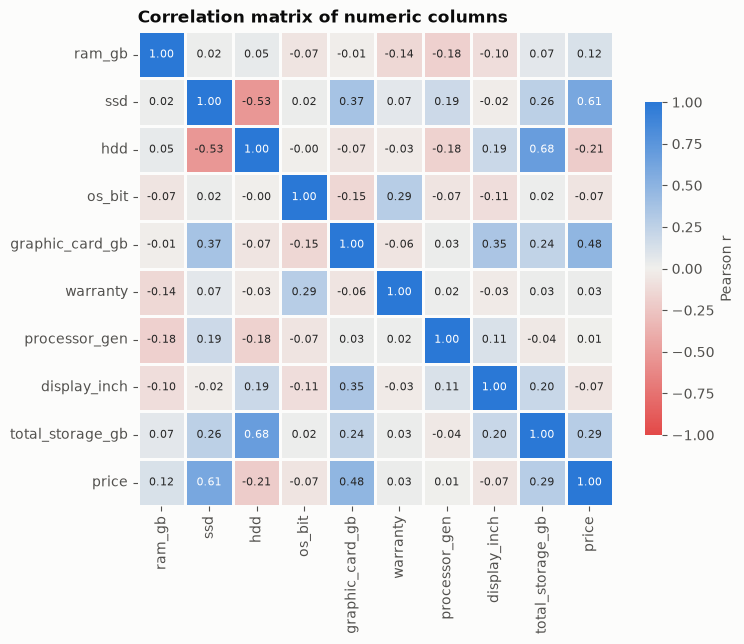

In [37]:
# Diverging colour scale: red (negative) - grey (zero) - blue (positive)
diverging = LinearSegmentedColormap.from_list("red_grey_blue", [RED, "#f0efec", BLUE])

corr_matrix = df[numeric_cols + ["price"]].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_matrix, cmap=diverging, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=2, linecolor=SURFACE, square=True,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix of numeric columns")
plt.tight_layout()
plt.show()

- **`ssd` (+0.61)** and **`graphic_card_gb` (+0.48)** have the strongest link with price, as the box plots
  showed.
- **`hdd` is negative (−0.21)**: laptops that still use a hard disk are cheaper models.
- `processor_gen` (+0.01), `warranty` (+0.03), `os_bit` (−0.07) and `display_inch` (−0.07) are close to 0:
  almost no straight-line relationship with price.
- In the matrix, `total_storage_gb` moves closely with `hdd` (+0.68). It is built from `ssd` and `hdd`, so it
  repeats their information (Step 12 deals with this).
- Correlation only covers numeric columns. Text columns (brand, CPU family…) are tested in Step 12.4.

## Step 11: Features and target separation

- **Target (`y`)**: `price`, the value we want to predict.
- **Features (`X`)**: every other column.

In [38]:
X = df.drop(columns=["price"])
y = df["price"]

print("X (features):", X.shape)
print("y (target)  :", y.shape)
print("\nFeature columns:", X.columns.tolist())

X (features): (832, 19)
y (target)  : (832,)

Feature columns: ['brand', 'model', 'processor_brand', 'processor_name', 'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb', 'laptop_type', 'warranty', 'touchscreen', 'msoffice', 'processor_gen', 'cpu_family', 'display_inch', 'total_storage_gb']


## Step 12: Feature Selection

Four checks decide which features the model keeps.

### 12.1 Drop columns with too many categories or a cleaner replacement

In [39]:
print("model          unique values:", X["model"].nunique(), "for", len(X), "laptops")
print("processor_name unique values:", X["processor_name"].nunique(), "-> replaced by cpu_family with",
      X["cpu_family"].nunique(), "values")

X = X.drop(columns=["model", "processor_name"])
print("\nDropped: model, processor_name  ->  X:", X.shape)

model          unique values: 106 for 832 laptops
processor_name unique values: 33 -> replaced by cpu_family with 10 values

Dropped: model, processor_name  ->  X: (832, 17)


- `model` has about one unique name for every 8 laptops; one-hot encoding it would add a column per name, most
  of them with only 1–2 laptops, which the model would simply memorise.
- `processor_name` is replaced by the clean `cpu_family` built in Step 3.

### 12.2 Drop redundant features

In [40]:
print("total_storage_gb == ssd + hdd for every laptop:",
      bool((X["total_storage_gb"] == X["ssd"] + X["hdd"]).all()))

X = X.drop(columns=["total_storage_gb"])
print("Dropped: total_storage_gb  ->  X:", X.shape)

total_storage_gb == ssd + hdd for every laptop: True
Dropped: total_storage_gb  ->  X: (832, 16)


`total_storage_gb` is an exact sum of `ssd` and `hdd`, so it adds no new information, and in Linear Regression
it makes the coefficients unstable (perfect multicollinearity). It was still useful for exploring the data.

### 12.3 Numeric features: F-test with `SelectKBest`

`f_regression` tests each numeric feature against `price`. A **p-value below 0.05** means the relationship is
unlikely to be chance, so the feature is kept.

In [41]:
num_features = X.select_dtypes(include="number").columns.tolist()
selector = SelectKBest(score_func=f_regression, k="all").fit(X[num_features], y)

num_scores = pd.DataFrame({"F score": selector.scores_.round(2), "p-value": selector.pvalues_.round(4)},
                          index=num_features).sort_values("F score", ascending=False)
num_scores["keep"] = num_scores["p-value"] < 0.05
num_scores

,F score,p-value,keep
ssd,486.38,0.0000,True
graphic_card_gb,253.64,0.0000,True
hdd,38.16,0.0000,True
ram_gb,12.93,0.0003,True
display_inch,4.07,0.0440,True
os_bit,3.96,0.0470,True
warranty,0.56,0.4545,False
processor_gen,0.04,0.8473,False


### 12.4 Categorical features: one-way ANOVA

For a text column, ANOVA checks whether the average price differs between its groups
(for example between `Windows` and `Mac` laptops). Again, **p < 0.05 → keep**.

In [42]:
cat_features = X.select_dtypes(exclude="number").columns.tolist()
anova_rows = []
for col in cat_features:
    groups = [group["price"].to_numpy() for _, group in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)
    anova_rows.append((col, X[col].nunique(), round(f_stat, 2), round(p_value, 4)))

cat_scores = pd.DataFrame(anova_rows, columns=["feature", "groups", "F score", "p-value"]).set_index("feature")
cat_scores["keep"] = cat_scores["p-value"] < 0.05
cat_scores.sort_values("F score", ascending=False)

,groups,F score,p-value,keep
feature,,,,
os,2,65.98,0.0000,True
laptop_type,3,36.11,0.0000,True
touchscreen,2,26.73,0.0000,True
processor_brand,5,14.50,0.0000,True
msoffice,2,11.22,0.0008,True
brand,20,10.49,0.0000,True
cpu_family,10,4.83,0.0000,True
ram_type,7,1.98,0.0657,False


### 12.5 Selected features

In [43]:
dropped_by_test = num_scores.index[~num_scores["keep"]].tolist() + cat_scores.index[~cat_scores["keep"]].tolist()
X = X.drop(columns=dropped_by_test)

num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

print("Dropped by the statistical tests:", dropped_by_test)
print(f"\nSelected numeric features    ({len(num_features)}):", num_features)
print(f"Selected categorical features ({len(cat_features)}):", cat_features)
print("\nX:", X.shape)

Dropped by the statistical tests: ['warranty', 'processor_gen', 'ram_type']

Selected numeric features    (6): ['ram_gb', 'ssd', 'hdd', 'os_bit', 'graphic_card_gb', 'display_inch']
Selected categorical features (7): ['brand', 'processor_brand', 'os', 'laptop_type', 'touchscreen', 'msoffice', 'cpu_family']

X: (832, 13)


**Result: 13 of the 19 features are kept.**

| Dropped | Reason |
|---|---|
| `model`, `processor_name` | Too many categories / replaced by `cpu_family` |
| `total_storage_gb` | Exact copy of `ssd + hdd` |
| `warranty`, `processor_gen` | F-test p-value above 0.05: no significant link with price |
| `ram_type` | ANOVA p-value 0.066, above 0.05 |

`display_inch` and `os_bit` only just pass (p ≈ 0.04–0.05); they are kept because they meet the rule.

## Step 13: Feature Scaling

The numeric features have very different ranges (RAM 4–16, SSD 0–3072). **StandardScaler** rescales each one to
mean 0 and standard deviation 1, so no feature dominates just because its numbers are bigger. This matters for
PCA (next step) and for distance- or coefficient-based models.

In [44]:
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X[num_features]), columns=num_features, index=X.index)

comparison = pd.DataFrame({
    "mean before": X[num_features].mean(), "std before": X[num_features].std(),
    "mean after": X_num_scaled.mean(), "std after": X_num_scaled.std(ddof=0),
}).round(3)
comparison

,mean before,std before,mean after,std after
ram_gb,9.755,4.071,0.0,1.0
ssd,481.269,290.086,0.0,1.0
hdd,172.308,382.490,-0.0,1.0
os_bit,59.269,11.365,0.0,1.0
graphic_card_gb,1.245,2.088,0.0,1.0
display_inch,14.784,0.947,-0.0,1.0


In [45]:
X_num_scaled.head()

,ram_gb,ssd,hdd,os_bit,graphic_card_gb,display_inch
0,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412
1,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412
2,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412
3,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412
4,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412


## Step 14: PCA (Principal Component Analysis)

PCA combines the scaled numeric features into new, uncorrelated components ordered by how much of the variation
(information) they keep. If a few components keep most of it, they can replace the original features.

In [46]:
pca = PCA()
X_pca = pca.fit_transform(X_num_scaled)

explained = pd.DataFrame({
    "component": [f"PC{i + 1}" for i in range(pca.n_components_)],
    "explained variance %": (pca.explained_variance_ratio_ * 100).round(1),
    "cumulative %": (np.cumsum(pca.explained_variance_ratio_) * 100).round(1),
}).set_index("component")
explained

,explained variance %,cumulative %
component,,
PC1,28.1,28.1
PC2,23.8,51.9
PC3,17.8,69.7
PC4,14.8,84.5
PC5,9.3,93.8
PC6,6.2,100.0


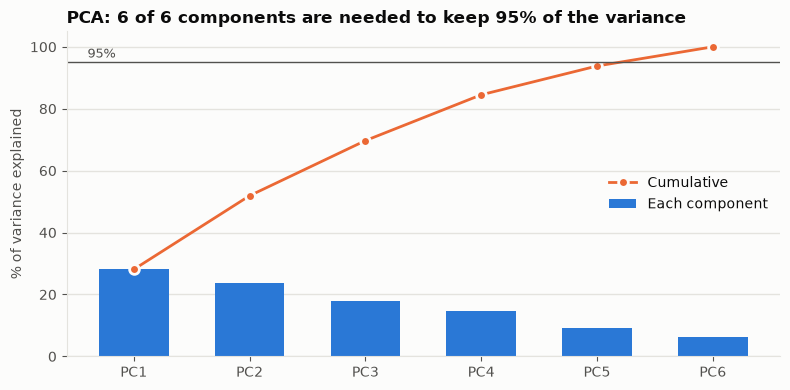

In [47]:
n_95 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, pca.n_components_ + 1)
ax.bar(x, explained["explained variance %"], color=BLUE, width=0.6, label="Each component")
ax.plot(x, explained["cumulative %"], color=ORANGE, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2, label="Cumulative")
ax.axhline(95, color=INK_2, linewidth=1)
ax.text(x[0] - 0.4, 96.5, "95%", color=INK_2, fontsize=9)
ax.set_xticks(x, explained.index)
ax.set_ylim(0, 105)
ax.set_ylabel("% of variance explained")
ax.set_title(f"PCA: {n_95} of {pca.n_components_} components are needed to keep 95% of the variance")
ax.legend(frameon=False, loc="center right")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

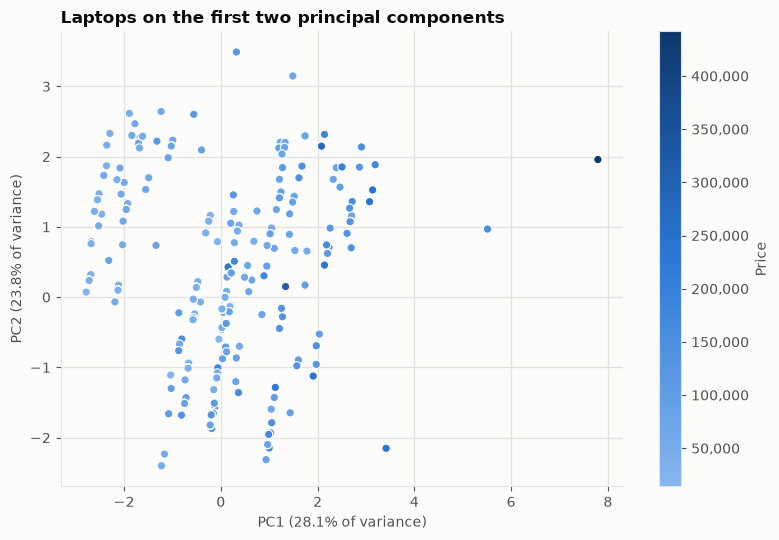

,PC1,PC2
ram_gb,-0.03,-0.08
ssd,0.67,-0.16
hdd,-0.54,0.41
os_bit,-0.09,-0.33
graphic_card_gb,0.49,0.47
display_inch,0.10,0.68


In [48]:
fig, ax = plt.subplots(figsize=(8, 5.5))
price_ramp = LinearSegmentedColormap.from_list("blue_ramp", ["#86b6ef", BLUE, "#0d366b"])  # light -> dark blue
points = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=price_ramp, s=36, edgecolors=SURFACE, linewidths=0.8)
cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Price")
cbar.formatter = thousands
cbar.update_ticks()
ax.set_title("Laptops on the first two principal components")
ax.set_xlabel(f"PC1 ({explained.iloc[0, 0]}% of variance)")
ax.set_ylabel(f"PC2 ({explained.iloc[1, 0]}% of variance)")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_[:2].T, index=num_features, columns=["PC1", "PC2"]).round(2)
loadings

- The 6 numeric features are only weakly correlated with each other, so the information is spread out: PC1 keeps
  28.1%, 5 components reach 93.8%, and all 6 are needed for 95%. PCA cannot shrink these features without
  losing information.
- PC1 is mostly `ssd` (+0.67) and `graphic_card_gb` (+0.49) against `hdd` (−0.54): a high PC1 means a laptop
  with a big SSD and a graphics card. In the scatter plot, the expensive (dark) laptops sit on the right, so PC1
  is linked to price.
- Step 17 tests PCA as a model step (**PCA + Linear Regression**) to see whether it helps accuracy.

## Step 15: Encoding

Models need numbers, so text columns are converted:

1. **Binary encoding:** `Yes` / `No` columns → 1 / 0.
2. **Rare brands:** brands with fewer than 10 laptops are grouped as `OTHER`, so they do not each get a nearly
   empty column.
3. **One-hot encoding** (`pd.get_dummies`): every other text column becomes one 0/1 column per category.
   `drop_first=True` drops one category per column (it is implied when all the others are 0).

In [49]:
X_enc = X.copy()

# 15.1 Binary encoding
binary_cols = [c for c in cat_features if set(X_enc[c].unique()) <= {"Yes", "No"}]
for col in binary_cols:
    X_enc[col] = X_enc[col].map({"Yes": 1, "No": 0})
print("Binary encoded (Yes=1, No=0):", binary_cols)

# 15.2 Group rare brands
brand_counts = X_enc["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index.tolist()
X_enc["brand"] = X_enc["brand"].where(~X_enc["brand"].isin(rare_brands), "OTHER")
print(f"\nRare brands grouped as OTHER ({len(rare_brands)}):", rare_brands)
print("Brands now:", sorted(X_enc["brand"].unique()))

Binary encoded (Yes=1, No=0): ['touchscreen', 'msoffice']

Rare brands grouped as OTHER (13): ['AVITA', 'LG', 'VAIO', 'REALME', 'NOKIA', 'INFINIX', 'ALIENWARE', 'REDMIBOOK', 'MICROSOFT', 'MI', 'SMARTRON', 'SAMSUNG', 'IBALL']
Brands now: ['ACER', 'APPLE', 'ASUS', 'DELL', 'HP', 'LENOVO', 'MSI', 'OTHER']


In [50]:
# 15.3 One-hot encoding
onehot_cols = [c for c in cat_features if c not in binary_cols]
X_enc = pd.get_dummies(X_enc, columns=onehot_cols, drop_first=True, dtype=int)

print("One-hot encoded:", onehot_cols)
print("Shape before encoding:", X.shape, " ->  after:", X_enc.shape)
X_enc.head()

One-hot encoded: ['brand', 'processor_brand', 'os', 'laptop_type', 'cpu_family']
Shape before encoding: (832, 13)  ->  after: (832, 31)


,ram_gb,ssd,hdd,os_bit,graphic_card_gb,touchscreen,msoffice,display_inch,brand_APPLE,brand_ASUS,brand_DELL,brand_HP,brand_LENOVO,brand_MSI,brand_OTHER,processor_brand_Apple,processor_brand_Intel,processor_brand_MediaTek,processor_brand_Qualcomm,os_Windows,laptop_type_Gaming,laptop_type_ThinNlight,cpu_family_AMD Ryzen 5,cpu_family_AMD Ryzen 7,cpu_family_AMD Ryzen 9,cpu_family_Apple M1,cpu_family_Entry level,cpu_family_Intel Core i3,cpu_family_Intel Core i5,cpu_family_Intel Core i7,cpu_family_Intel Core i9
0,4,0,1024,64,0,0,0,15.6,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,4,512,0,64,0,0,0,15.6,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,4,512,0,64,0,0,1,15.6,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,4,512,0,64,0,0,0,15.6,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,4,0,1024,64,0,0,1,15.6,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0


In [51]:
print("Every column is numeric now:", X_enc.select_dtypes(exclude="number").empty)
print("\nNew columns:")
for col in onehot_cols:
    print(f"  {col:<16} ->", [c for c in X_enc.columns if c.startswith(col + "_") and c not in X.columns])

Every column is numeric now: True

New columns:
  brand            -> ['brand_APPLE', 'brand_ASUS', 'brand_DELL', 'brand_HP', 'brand_LENOVO', 'brand_MSI', 'brand_OTHER']
  processor_brand  -> ['processor_brand_Apple', 'processor_brand_Intel', 'processor_brand_MediaTek', 'processor_brand_Qualcomm']
  os               -> ['os_Windows']
  laptop_type      -> ['laptop_type_Gaming', 'laptop_type_ThinNlight']
  cpu_family       -> ['cpu_family_AMD Ryzen 5', 'cpu_family_AMD Ryzen 7', 'cpu_family_AMD Ryzen 9', 'cpu_family_Apple M1', 'cpu_family_Entry level', 'cpu_family_Intel Core i3', 'cpu_family_Intel Core i5', 'cpu_family_Intel Core i7', 'cpu_family_Intel Core i9']


### The final feature matrix

Putting the steps together: scaled numeric features (Step 13) + encoded categorical features (Step 15). This is
what a model sees.

In [52]:
X_final = pd.concat([X_num_scaled, X_enc.drop(columns=num_features)], axis=1)
print("Final feature matrix:", X_final.shape)
X_final.head()

Final feature matrix: (832, 31)


,ram_gb,ssd,hdd,os_bit,graphic_card_gb,display_inch,touchscreen,msoffice,brand_APPLE,brand_ASUS,brand_DELL,brand_HP,brand_LENOVO,brand_MSI,brand_OTHER,processor_brand_Apple,processor_brand_Intel,processor_brand_MediaTek,processor_brand_Qualcomm,os_Windows,laptop_type_Gaming,laptop_type_ThinNlight,cpu_family_AMD Ryzen 5,cpu_family_AMD Ryzen 7,cpu_family_AMD Ryzen 9,cpu_family_Apple M1,cpu_family_Entry level,cpu_family_Intel Core i3,cpu_family_Intel Core i5,cpu_family_Intel Core i7,cpu_family_Intel Core i9
0,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0


### Features passed to the models

The models (Steps 16–20) get the **selected and encoded** features from Step 15, not the scaled matrix above.

Why? Scaling and PCA *learn* from the data (means, standard deviations, components). In Step 17 they are fitted on
the **training set only**, inside a pipeline, so the test set stays unseen. Fitting them on all rows here would
let information from the test laptops leak into training (*data leakage*).

In [53]:
X = X_enc.copy()        # from here on, X is the encoded feature table

# Numeric features are scaled inside the model pipeline; 0/1 columns (encoded categories, Yes/No flags) are left as they are.
numeric_features = [c for c in X.columns if not set(X[c].unique()) <= {0, 1}]
print("X:", X.shape, "  y:", y.shape)
print("Numeric features to scale:", numeric_features)

X: (832, 31)   y: (832,)
Numeric features to scale: ['ram_gb', 'ssd', 'hdd', 'os_bit', 'graphic_card_gb', 'display_inch']


## Step 16: Train Test Split

80% of the laptops train the models; the other 20% are held back to test them on laptops they have never seen.
`random_state=42` makes the split the same every time the notebook runs.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} laptops ({X_train.shape[0] / len(X):.0%})")
print(f"Test set    : {X_test.shape[0]} laptops ({X_test.shape[0] / len(X):.0%})")

pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(0)

Training set: 665 laptops (80%)
Test set    : 167 laptops (20%)


,train,test
count,665.0,167.0
mean,77823.0,74958.0
std,48061.0,41873.0
min,17490.0,13990.0
25%,46990.0,45490.0
50%,63990.0,64990.0
75%,92990.0,87990.0
max,441990.0,225990.0


Both sets have a similar price range and average, so the test set is a fair sample.

## Step 17: Model Preparation

Every model is a **pipeline**: the preprocessing (scaling, and PCA for one model) is part of the model, so it
is fitted on the training data only — on `fit()` here and inside each fold in cross-validation.

| Model | How it predicts |
|---|---|
| Linear Regression | price = weighted sum of the features (a straight-line relationship) |
| PCA + Linear Regression | the same, but on principal components (Step 14) of all scaled features, keeping 95% of the variance |
| Decision Tree | a series of yes/no questions about the features (max depth 8 to limit overfitting) |
| Random Forest | the average of 300 decision trees, each trained on a random sample |
| Gradient Boosting | trees added one at a time, each correcting the errors of the previous ones |

In [55]:
def scale_numeric():
    """Scale numeric columns and pass the 0/1 columns through unchanged."""
    return ColumnTransformer([("scale", StandardScaler(), numeric_features)], remainder="passthrough")


models = {
    "Linear Regression": Pipeline([
        ("scale", scale_numeric()),
        ("model", LinearRegression()),
    ]),
    "PCA + Linear Regression": Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("model", LinearRegression()),
    ]),
    "Decision Tree": Pipeline([
        ("scale", scale_numeric()),
        ("model", DecisionTreeRegressor(max_depth=8, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("scale", scale_numeric()),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("scale", scale_numeric()),
        ("model", GradientBoostingRegressor(random_state=42)),
    ]),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

n_pca = models["PCA + Linear Regression"].named_steps["pca"].n_components_
print(f"\nPCA kept {n_pca} of {X.shape[1]} columns to explain 95% of the variance.")

Trained: Linear Regression
Trained: PCA + Linear Regression
Trained: Decision Tree


Trained: Random Forest
Trained: Gradient Boosting

PCA kept 23 of 31 columns to explain 95% of the variance.


## Step 18: Model Accuracy

For a regression model (predicting a number, not a class), accuracy is measured with:

- **R² score** — the main "accuracy" for regression: 1.0 = perfect, 0 = no better than always guessing the
  average price. Compared on the **training** and **test** sets: a big gap means the model memorised the
  training data (*overfitting*).
- **MAE** — mean absolute error: on average, how far the predicted price is from the real price.
- **RMSE** — root mean squared error: like MAE, but large mistakes count more.
- **Within ±20%** — share of test laptops whose predicted price is within 20% of the real price.

In [56]:
rows = []
for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    rows.append({
        "model": name,
        "train R2": r2_score(y_train, train_pred),
        "test R2": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "within ±20%": np.mean(np.abs(test_pred - y_test) / y_test <= 0.20) * 100,
    })

accuracy = pd.DataFrame(rows).set_index("model").sort_values("test R2", ascending=False)
accuracy.style.format({"train R2": "{:.3f}", "test R2": "{:.3f}", "MAE": "{:,.0f}",
                       "RMSE": "{:,.0f}", "within ±20%": "{:.1f}%"})

,train R2,test R2,MAE,RMSE,within ±20%
model,,,,,
Gradient Boosting,0.814,0.652,"16,335","24,622",61.1%
Linear Regression,0.646,0.631,"18,116","25,375",48.5%
PCA + Linear Regression,0.525,0.500,"22,459","29,518",42.5%
Decision Tree,0.856,0.462,"18,278","30,620",59.3%
Random Forest,0.933,0.455,"17,521","30,810",59.3%


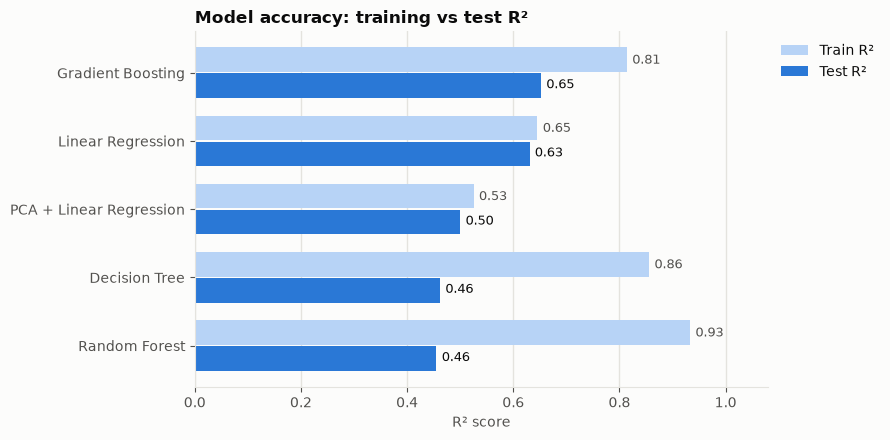

In [57]:
order = accuracy.sort_values("test R2").index
ypos = np.arange(len(order))
bar_h = 0.36

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ypos + bar_h / 2 + 0.01, accuracy.loc[order, "train R2"], height=bar_h, color=BLUE_LIGHT, label="Train R²")
ax.barh(ypos - bar_h / 2 - 0.01, accuracy.loc[order, "test R2"], height=bar_h, color=BLUE, label="Test R²")
for y_, (tr, te) in enumerate(zip(accuracy.loc[order, "train R2"], accuracy.loc[order, "test R2"])):
    ax.text(tr + 0.01, y_ + bar_h / 2, f"{tr:.2f}", va="center", color=INK_2, fontsize=9)
    ax.text(te + 0.01, y_ - bar_h / 2, f"{te:.2f}", va="center", color=INK, fontsize=9)
ax.set_yticks(ypos, order)
ax.set_xlim(0, 1.08)
ax.set_xlabel("R² score")
ax.set_title("Model accuracy: training vs test R²")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

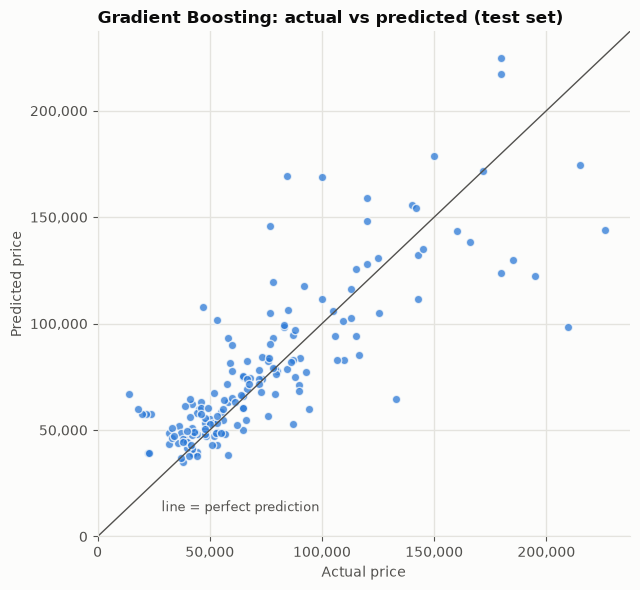

In [58]:
best_name = accuracy.index[0]
best_pred = models[best_name].predict(X_test)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, best_pred, s=36, color=BLUE, alpha=0.75, edgecolors=SURFACE, linewidths=1)
limit = [0, max(y_test.max(), best_pred.max()) * 1.05]
ax.plot(limit, limit, color=INK_2, linewidth=1)
ax.text(limit[1] * 0.12, limit[1] * 0.05, "line = perfect prediction", color=INK_2, fontsize=9)
ax.set_xlim(limit)
ax.set_ylim(limit)
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.xaxis.set_major_formatter(thousands)
ax.yaxis.set_major_formatter(thousands)
ax.set_title(f"{best_name}: actual vs predicted (test set)")
plt.tight_layout()
plt.show()

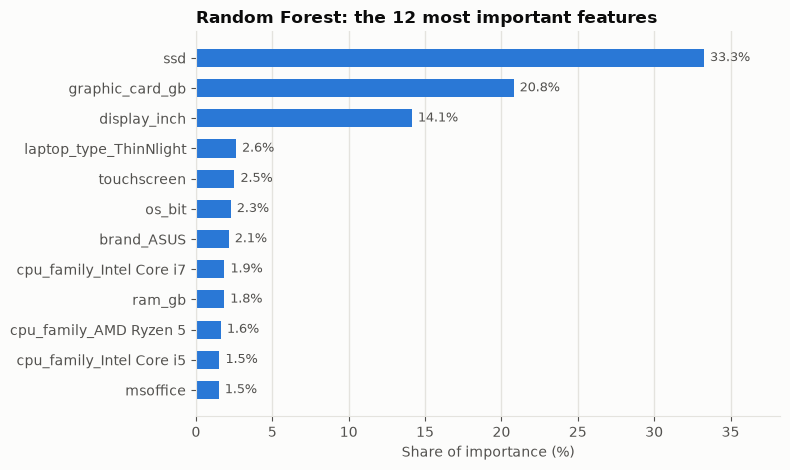

In [59]:
forest = models["Random Forest"].named_steps["model"]
feature_names = models["Random Forest"].named_steps["scale"].get_feature_names_out()
feature_names = [n.split("__", 1)[1] for n in feature_names]           # drop the "scale__" prefix
importance = pd.Series(forest.feature_importances_, index=feature_names).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(importance.index, importance * 100, color=BLUE, height=0.6)
for y_, v in enumerate(importance * 100):
    ax.text(v + 0.4, y_, f"{v:.1f}%", va="center", color=INK_2, fontsize=9)
ax.set_title("Random Forest: the 12 most important features")
ax.set_xlabel("Share of importance (%)")
ax.set_xlim(0, importance.max() * 100 * 1.15)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

- **Gradient Boosting** has the best test accuracy: **R² = 0.652**, an average error (MAE) of about 16,300, and
  61% of test laptops predicted within ±20% of their real price.
- **Linear Regression** is close behind (R² 0.631), and its train and test scores are almost equal (0.646 vs
  0.631): it does not overfit.
- **Decision Tree** and **Random Forest** score very well on the training data (0.86 and 0.93) but only about
  0.46 on the test set: they **overfit**, memorising the training laptops.
- **PCA + Linear Regression** is worse than plain Linear Regression (0.500 vs 0.631). PCA kept 23 of the 31
  columns, and the variance it dropped still carried price information.
- `ssd` and `graphic_card_gb` are the Random Forest's most important features, matching the correlation check in
  Step 10. `display_inch` comes third: it helps in combination with other features even though its own
  correlation with price is weak.

## Step 19: Cross_val function

One train/test split can be lucky or unlucky. **K-fold cross-validation** splits the data into 5 parts (folds);
each fold is the test set once while the other 4 train the model. The 5 scores show how stable the accuracy is.

In [60]:
def cross_val(model, X, y, folds=5, show=True):
    """Return the R² score of `model` on each of `folds` cross-validation folds."""
    kfold = KFold(n_splits=folds, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")
    if show:
        print("R² per fold:", np.round(scores, 3))
        print(f"Mean R²    : {scores.mean():.3f}   (std {scores.std():.3f})")
    return scores


# Example: cross-validate Linear Regression
lr_scores = cross_val(models["Linear Regression"], X, y)

R² per fold: [0.631 0.538 0.582 0.561 0.678]
Mean R²    : 0.598   (std 0.050)


## Step 20: cross_val Accuracy

In [61]:
cv_scores = {}
for name, model in models.items():
    print(f"--- {name} ---")
    cv_scores[name] = cross_val(model, X, y)
    print()

--- Linear Regression ---
R² per fold: [0.631 0.538 0.582 0.561 0.678]
Mean R²    : 0.598   (std 0.050)

--- PCA + Linear Regression ---


R² per fold: [0.5   0.444 0.47  0.392 0.543]
Mean R²    : 0.470   (std 0.051)

--- Decision Tree ---
R² per fold: [0.462 0.31  0.622 0.445 0.413]
Mean R²    : 0.450   (std 0.101)

--- Random Forest ---


R² per fold: [0.467 0.606 0.777 0.586 0.581]
Mean R²    : 0.603   (std 0.100)

--- Gradient Boosting ---


R² per fold: [0.651 0.639 0.73  0.475 0.564]
Mean R²    : 0.612   (std 0.087)



In [62]:
cv_table = pd.DataFrame({
    "mean R2": {n: s.mean() for n, s in cv_scores.items()},
    "std": {n: s.std() for n, s in cv_scores.items()},
    "min": {n: s.min() for n, s in cv_scores.items()},
    "max": {n: s.max() for n, s in cv_scores.items()},
}).sort_values("mean R2", ascending=False)
cv_table["test R2 (Step 18)"] = accuracy["test R2"]
cv_table.round(3)

,mean R2,std,min,max,test R2 (Step 18)
Gradient Boosting,0.612,0.087,0.475,0.730,0.652
Random Forest,0.603,0.100,0.467,0.777,0.455
Linear Regression,0.598,0.050,0.538,0.678,0.631
PCA + Linear Regression,0.470,0.051,0.392,0.543,0.500
Decision Tree,0.450,0.101,0.310,0.622,0.462


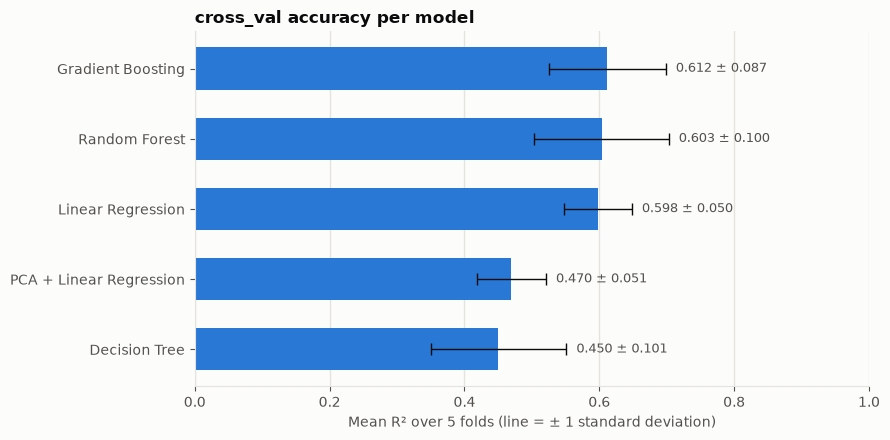

In [63]:
plot_cv = cv_table.sort_values("mean R2")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_cv.index, plot_cv["mean R2"], color=BLUE, height=0.6)
ax.errorbar(plot_cv["mean R2"], np.arange(len(plot_cv)), xerr=plot_cv["std"], fmt="none",
            ecolor=INK, elinewidth=1, capsize=4)
for y_, (m, s) in enumerate(zip(plot_cv["mean R2"], plot_cv["std"])):
    ax.text(m + s + 0.015, y_, f"{m:.3f} ± {s:.3f}", va="center", color=INK_2, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("Mean R² over 5 folds (line = ± 1 standard deviation)")
ax.set_title("cross_val accuracy per model")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Predictions for a few test laptops

In [64]:
final_name = cv_table.index[0]
final_model = models[final_name]

sample = X_test.head(10)
predicted = pd.DataFrame({
    "actual price": y_test.loc[sample.index],
    "predicted price": final_model.predict(sample),
})
predicted["error %"] = (predicted["predicted price"] - predicted["actual price"]) / predicted["actual price"] * 100
print("Model:", final_name)
predicted.style.format({"actual price": "{:,.0f}", "predicted price": "{:,.0f}", "error %": "{:+.1f}%"})

Model: Gradient Boosting


,actual price,predicted price,error %
610,"58,100","93,382",+60.7%
819,"57,990","38,491",-33.6%
290,"64,990","74,892",+15.2%
559,"142,990","132,317",-7.5%
168,"82,990","98,418",+18.6%
687,"119,990","148,148",+23.5%
818,"94,190","59,971",-36.3%
86,"52,990","42,990",-18.9%
260,"41,990","62,211",+48.2%
547,"66,490","69,113",+3.9%


## Conclusion

- **Data preparation mattered most.** Hidden missing values (`"Missing"`, 0-inch screens, non-RAM values…) and
  10 duplicate rows were fixed, and 34 messy processor names became 10 CPU families.
- **What drives price:** SSD size, graphics card memory and brand (Apple and MSI are the most expensive).
- **Best model:** after 5-fold cross-validation, **Gradient Boosting** (mean R² **0.612** ± 0.087), just ahead of
  Random Forest (0.603) and Linear Regression (0.598). Linear Regression is the most stable (std 0.050).
- **What R² ≈ 0.6 means:** the models explain about 60% of the price differences between laptops. The rest comes
  from information the data does not contain, or that was scraped into the wrong column (for example CPU
  families whose prices do not follow CPU power).
- **Why cross-validation:** for Random Forest, the single test split (Step 18) gave 0.455, but cross-validation
  gave 0.603. One split can be lucky or unlucky; the cross_val accuracy is the more reliable number.

**Possible improvements:** tune the model settings with `GridSearchCV`, predict `log(price)` to reduce the
effect of the very expensive laptops, and collect cleaner data for the processor and RAM columns.